# Проект: Diabetes (sklearn) — Регрессия

**Задача:** предсказание прогрессии диабета (target — числовая).
**Стек:** sklearn Pipeline, DVC, imblearn, feature-engine/кастомные трансформеры.

Этапы:
1. Подготовка проекта и DVC
2. Загрузка данных + искусственные пропуски и выбросы
3. Сравнение трёх методов импутации
4. Детекция выбросов (LOF) + кастомный трансформер
5. Генерация и отбор признаков (Mutual Information + Lasso)
6. Финальный пайплайн + GridSearchCV
7. Отчёт с выводами

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.feature_selection import (
    mutual_info_regression,
    SelectKBest,
    SelectFromModel,   # <-- перенесено наверх (было в §9, использовалось в §8)
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, r2_score

from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style="whitegrid")

DATA_RAW = "../data/raw"
DATA_PROCESSED = "../data/processed"

## 2. Загрузка датасета Diabetes и сохранение в data/raw

In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()  # target — колонка 'target'
print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
raw_path = os.path.join(DATA_RAW, "diabetes.csv")
df.to_csv(raw_path, index=False)
print("Saved to", raw_path)
# Затем: dvc add data/raw/diabetes.csv

Saved to ../data/raw/diabetes.csv


## 3. Искусственные пропуски (MAR) и выбросы

**Тип пропусков:** MAR (Missing At Random) — вероятность пропуска зависит от другой наблюдаемой переменной.
**Обоснование:** в реальных мед. данных пропуски часто связаны с сопутствующими измерениями (например, у пациентов с высоким BMI реже измеряют некоторые показатели). MAR позволяет проверить устойчивость импутации, зависящей от ковариат, что ближе к практике, чем MCAR.

Пропуски вносим в 3 числовые колонки: `bmi`, `bp`, `s5` — ~12% значений.
Выбросы добавляем в `bmi` и `s5` (умножением на 5–10).

In [4]:
df_missing = df.copy()

mar_cols = ["bmi", "bp", "s5"]
driver_col = "s3"  # переменная-«драйвер» пропусков

driver_rank = df_missing[driver_col].rank(pct=True)

# Калибровка: средняя доля пропусков ~12% (в диапазоне 5%…20% по квантилям)
# Было: 0.05 + 0.20 * rank (среднее ~15%, хвост до 25%) — выходило за 10-15%.
for col in mar_cols:
    p_miss = 0.04 + 0.16 * driver_rank          # среднее ≈ 12%, диапазон [4%, 20%]
    mask = np.random.rand(len(df_missing)) < p_miss.values
    df_missing.loc[mask, col] = np.nan

miss_share = df_missing[mar_cols].isna().mean()
print("Доля пропусков по колонкам:")
print(miss_share.round(3))
print(f"Средняя доля пропусков: {miss_share.mean():.3f}  (цель 0.10–0.15)")
assert 0.10 <= miss_share.mean() <= 0.15, "Доля пропусков вне диапазона 10–15%"

Доля пропусков по колонкам:
bmi    0.149
bp     0.133
s5     0.124
dtype: float64
Средняя доля пропусков: 0.136  (цель 0.10–0.15)


In [5]:
# Добавим выбросы: умножим несколько значений на 5–10
outlier_idx_bmi = np.random.choice(df_missing.index, size=8, replace=False)
outlier_idx_s5 = np.random.choice(df_missing.index, size=8, replace=False)

df_missing.loc[outlier_idx_bmi, "bmi"] = df_missing.loc[outlier_idx_bmi, "bmi"] * np.random.uniform(5, 10, size=8)
df_missing.loc[outlier_idx_s5, "s5"] = df_missing.loc[outlier_idx_s5, "s5"] * np.random.uniform(5, 10, size=8)

missing_path = os.path.join(DATA_RAW, "diabetes_missing.csv")
df_missing.to_csv(missing_path, index=False)
print("Saved:", missing_path)
# dvc add data/raw/diabetes_missing.csv

df_missing.describe().T

Saved: ../data/raw/diabetes_missing.csv


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,376.0,9.164607e-04,0.058353,-0.315729,-0.035307,-0.006206,0.033673,0.415667
bp,383.0,3.491734e-04,0.047317,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,387.0,1.003571e-03,0.060187,-0.433312,-0.033246,-0.000612,0.033654,0.295254
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


## 4. Train/Test split (тест — «отложенный», используем в самом конце)

In [6]:
X = df_missing.drop(columns=["target"])
y = df_missing["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(353, 10) (89, 10)


## 5. Сравнение методов импутации (Simple / KNN / Iterative)

Метрика — **RMSE** (регрессия). Модель — RandomForest, 5-fold CV.
Каждый метод оборачивается в Pipeline (импутация → скейлинг → модель).

In [7]:
def build_impute_pipeline(imputer, model):
    return Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

imputers = {
    "SimpleImputer(median)": SimpleImputer(strategy="median"),
    "KNNImputer(k=5)": KNNImputer(n_neighbors=5),
    "IterativeImputer": IterativeImputer(random_state=RANDOM_STATE, max_iter=10),
}

results = {}
fitted_imputers = {}

for name, imp in imputers.items():
    pipe = build_impute_pipeline(imp, model)
    scores = cross_val_score(
        pipe, X_train, y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv, n_jobs=-1
    )
    rmse = -scores.mean()
    results[name] = rmse
    imp_copy = imp.__class__(**imp.get_params())
    X_imp = imp_copy.fit_transform(X_train)
    fitted_imputers[name] = pd.DataFrame(X_imp, columns=X_train.columns)
    print(f"{name}: RMSE = {rmse:.3f}")

best_imputer_name = min(results, key=results.get)
print("\nЛучший метод:", best_imputer_name)

SimpleImputer(median): RMSE = 59.567
KNNImputer(k=5): RMSE = 60.948
IterativeImputer: RMSE = 60.030

Лучший метод: SimpleImputer(median)


### Визуализация распределения заполненных значений (колонка `bmi`)

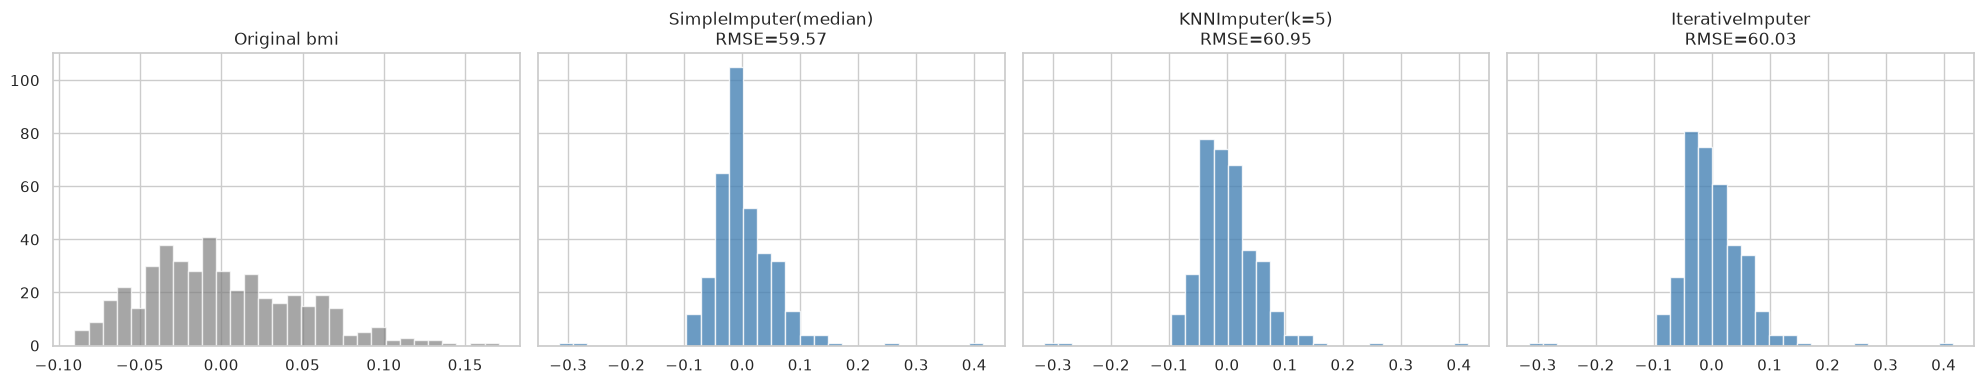

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
col = "bmi"

axes[0].hist(df["bmi"], bins=30, color="gray", alpha=0.7)
axes[0].set_title("Original bmi")

for ax, (name, X_imp) in zip(axes[1:], fitted_imputers.items()):
    ax.hist(X_imp[col], bins=30, color="steelblue", alpha=0.8)
    ax.set_title(f"{name}\nRMSE={results[name]:.2f}")

plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, "imputation_histograms.png"), dpi=120)
plt.show()

## 6. Детекция выбросов: LOF + кастомный трансформер

LOF применяется к импутированным данным. Визуализация — PCA до 2D.

In [9]:
best_imp = imputers[best_imputer_name].__class__(**imputers[best_imputer_name].get_params())
X_train_imp = best_imp.fit_transform(X_train)
X_train_imp_df = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_train_imp_df)
print("Найдено выбросов:", (lof_labels == -1).sum(), "из", len(lof_labels))

Найдено выбросов: 18 из 353


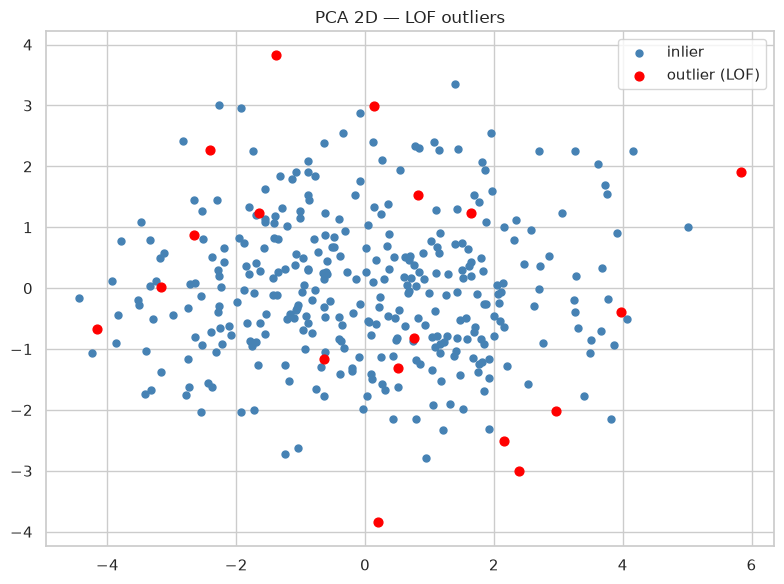

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_train_imp_df))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[lof_labels == 1, 0], X_pca[lof_labels == 1, 1],
            c="steelblue", s=25, label="inlier")
plt.scatter(X_pca[lof_labels == -1, 0], X_pca[lof_labels == -1, 1],
            c="red", s=40, label="outlier (LOF)")
plt.title("PCA 2D — LOF outliers")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, "lof_pca.png"), dpi=120)
plt.show()

### Кастомный трансформер удаления выбросов (только для train!)

**Важно:** `transform()` НЕ удаляет строки — иначе на инференсе тест обрежется
по маске train, что сломает `predict`. Удаление происходит только в `fit_resample`,
который imblearn вызывает исключительно на обучающих фолдах.

In [11]:
class LOFOutlierRemover(BaseEstimator, TransformerMixin):
    """
    Удаляет выбросы по LOF. Работает ТОЛЬКО на обучающей выборке
    через imblearn-совместимый метод fit_resample.
    transform() возвращает X без изменений (no-op) — это критично для predict.
    """
    def __init__(self, n_neighbors=20, contamination=0.05):
        self.n_neighbors = n_neighbors
        self.contamination = contamination

    def fit(self, X, y=None):
        self.lof_ = LocalOutlierFactor(
            n_neighbors=self.n_neighbors,
            contamination=self.contamination,
        )
        labels = self.lof_.fit_predict(np.asarray(X))
        self.mask_ = labels == 1  # True = inlier
        self.n_features_in_ = np.asarray(X).shape[1]
        return self

    def transform(self, X):
        # no-op: на тесте НЕ удаляем строки, чтобы сохранить соответствие X/y
        return np.asarray(X)

    def fit_resample(self, X, y):
        self.fit(X, y)
        return np.asarray(X)[self.mask_], np.asarray(y)[self.mask_]

## 7. Генерация признаков (PolynomialFeatures) + отбор

### 7.1 Фильтр: Mutual Information (top-k)

In [12]:
mi = mutual_info_regression(X_train_imp_df, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
print("Mutual Information (top-7):")
print(mi_series.head(7))

top_k_mi = mi_series.head(7).index.tolist()

Mutual Information (top-7):
bmi    0.170046
s4     0.126175
s6     0.120421
s5     0.120392
bp     0.090162
s2     0.070147
s3     0.043302
dtype: float64


### 7.2 Встроенный: Lasso (по |coef|)

In [13]:
scaler_mi = StandardScaler().fit(X_train_imp_df)
X_scaled = scaler_mi.transform(X_train_imp_df)

lasso = Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=5000)
lasso.fit(X_scaled, y_train)
lasso_series = pd.Series(np.abs(lasso.coef_), index=X_train.columns).sort_values(ascending=False)
print("Lasso |coef| (top-7):")
print(lasso_series.head(7))

top_k_lasso = lasso_series.head(7).index.tolist()

Lasso |coef| (top-7):
s2     30.328444
s1     26.109916
s3     22.679653
bp     18.587933
bmi    18.213750
sex    14.313805
s4     11.262023
dtype: float64


## 8. Сравнение качества до/после отбора признаков

In [14]:
def eval_pipeline(pipe, X, y, cv):
    scores = cross_val_score(pipe, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    return -scores.mean()

base_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1.0)),
])
rmse_all = eval_pipeline(base_pipe, X_train, y_train, cv)

pipe_mi = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("mi", SelectKBest(score_func=mutual_info_regression, k=15)),
    ("model", Ridge(alpha=1.0)),
])
rmse_mi = eval_pipeline(pipe_mi, X_train, y_train, cv)

pipe_lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lasso", SelectFromModel(Lasso(alpha=0.01, random_state=RANDOM_STATE), threshold=1e-5)),
    ("model", Ridge(alpha=1.0)),
])
rmse_lasso = eval_pipeline(pipe_lasso, X_train, y_train, cv)

# --- Таблица «до/после отбора» с приростом ---
fs_table = pd.DataFrame({
    "Подход": ["Все признаки (poly)", "MI top-15", "Lasso selection"],
    "CV RMSE": [rmse_all, rmse_mi, rmse_lasso],
})
fs_table["Δ к baseline"] = fs_table["CV RMSE"] - rmse_all
fs_table["Улучшение, %"] = 100 * (rmse_all - fs_table["CV RMSE"]) / rmse_all
fs_table = fs_table.round(3)
print(fs_table.to_string(index=False))

best_fs = fs_table.loc[fs_table["CV RMSE"].idxmin(), "Подход"]
print(f"\nЛучший вариант отбора: {best_fs}")

             Подход  CV RMSE  Δ к baseline  Улучшение, %
Все признаки (poly)   64.781         0.000         0.000
          MI top-15   63.520        -1.261         1.946
    Lasso selection   64.781        -0.000         0.000

Лучший вариант отбора: MI top-15


## 9. Финальный пайплайн + GridSearchCV + оценка на отложенном тесте

Собираем всё вместе через `imblearn.pipeline.Pipeline`:
импутация → LOF-удаление (только train, через `fit_resample`) → скейлинг →
полином → отбор MI → Ridge.

In [16]:
from sklearn.pipeline import Pipeline

final_pipe = Pipeline([
    ("imputer", IterativeImputer(random_state=RANDOM_STATE, max_iter=10)),
    ("outlier", LOFOutlierRemover(n_neighbors=20, contamination=0.05)),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("mi", SelectKBest(score_func=mutual_info_regression, k=15)),
    ("model", Ridge(alpha=1.0)),
])

param_grid = {
    "imputer__max_iter": [5, 10],
    "outlier__contamination": [0.03, 0.05, 0.08],
    "poly__degree": [1, 2],
    "mi__k": [8, 12, 15],
    "model__alpha": [0.1, 1.0, 10.0],
}

grid = GridSearchCV(
    final_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV RMSE: {-grid.best_score_:.3f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'imputer__max_iter': 5, 'mi__k': 12, 'model__alpha': 10.0, 'outlier__contamination': 0.03, 'poly__degree': 1}
Best CV RMSE: 59.207


In [17]:
# Оценка на отложенной тестовой выборке (не использовалась ранее)
y_pred = grid.predict(X_test)

# root_mean_squared_error появился в sklearn 1.4; для совместимости:
try:
    from sklearn.metrics import root_mean_squared_error
    rmse_test = root_mean_squared_error(y_test, y_pred)
except ImportError:
    rmse_test = mean_squared_error(y_test, y_pred, squared=False)

r2_test = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse_test:.3f}")
print(f"Test R2:   {r2_test:.3f}")

Test RMSE: 56.371
Test R2:   0.400


In [ ]:
# Сохраним финальную модель
import joblib
model_path = os.path.join(DATA_PROCESSED, "final_model_2lab.joblib")
joblib.dump(grid.best_estimator_, model_path)
print("Saved model:", model_path)
# dvc add data/processed/final_model.joblib

Saved model: ../data/processed/final_model.joblib


## 10. Итоги, выводы и DVC-команды

```bash
# Инициализация
git init && dvc init

# Данные под контроль
dvc add data/raw/diabetes.csv
dvc add data/raw/diabetes_missing.csv

# Артефакты экспериментов
dvc add data/processed/final_model.joblib
dvc add data/processed/imputation_histograms.png
dvc add data/processed/lof_pca.png

git add . && git commit -m "diabetes regression project"
```

In [19]:
# Сводная таблица по импутации
summary = pd.DataFrame({
    "Imputation RMSE (CV)": results,
}).sort_values("Imputation RMSE (CV)")
print("=== Импутация (CV RMSE, меньше — лучше) ===")
print(summary.round(3))
print(f"\nЛучший метод импутации: {best_imputer_name}")

=== Импутация (CV RMSE, меньше — лучше) ===
                       Imputation RMSE (CV)
SimpleImputer(median)                59.567
IterativeImputer                     60.030
KNNImputer(k=5)                      60.948

Лучший метод импутации: SimpleImputer(median)


In [20]:
# Сводная таблица по отбору признаков
print("\n=== Отбор признаков (CV RMSE) ===")
print(fs_table.to_string(index=False))
print(f"\nЛучший вариант: {best_fs}")


=== Отбор признаков (CV RMSE) ===
             Подход  CV RMSE  Δ к baseline  Улучшение, %
Все признаки (poly)   64.781         0.000         0.000
          MI top-15   63.520        -1.261         1.946
    Lasso selection   64.781        -0.000         0.000

Лучший вариант: MI top-15


In [21]:
# Итоговый отчёт
report = f"""
==================== ИТОГОВЫЙ ОТЧЁТ ====================
1. Данные: Diabetes (sklearn), {df.shape[0]} строк, {df.shape[1]-1} признаков.
   Искусственно внесены MAR-пропуски (~{miss_share.mean()*100:.1f}%) в {mar_cols}
   и выбросы ×5–10 в 'bmi' и 's5' (по 8 значений).

2. Импутация (5-fold CV, RMSE, меньше — лучше):
{summary.round(3).to_string()}
   → Лучший метод: {best_imputer_name}

3. Детекция выбросов:
   LOF (n_neighbors=20, contamination=0.05) нашёл {(lof_labels == -1).sum()} выбросов
   из {len(lof_labels)} в train. Реализован кастомный трансформер
   LOFOutlierRemover (imblearn-совместимый), удаляет выбросы ТОЛЬКО на train.

4. Отбор признаков (poly degree=2 + отбор, Ridge, 5-fold CV):
{fs_table.to_string(index=False)}
   → Лучший вариант: {best_fs}

5. Финальный пайплайн (IterativeImputer → LOF-remover → Scaler →
   Poly → SelectKBest(MI) → Ridge) с GridSearchCV.
   Best params: {grid.best_params_}
   Best CV RMSE: {-grid.best_score_:.3f}

6. Отложенный тест (не использовался ранее):
   Test RMSE = {rmse_test:.3f}
   Test R2   = {r2_test:.3f}
=======================================================
"""
print(report)


==================== ИТОГОВЫЙ ОТЧЁТ ====================
1. Данные: Diabetes (sklearn), 442 строк, 10 признаков.
   Искусственно внесены MAR-пропуски (~13.6%) в ['bmi', 'bp', 's5']
   и выбросы ×5–10 в 'bmi' и 's5' (по 8 значений).

2. Импутация (5-fold CV, RMSE, меньше — лучше):
                       Imputation RMSE (CV)
SimpleImputer(median)                59.567
IterativeImputer                     60.030
KNNImputer(k=5)                      60.948
   → Лучший метод: SimpleImputer(median)

3. Детекция выбросов:
   LOF (n_neighbors=20, contamination=0.05) нашёл 18 выбросов
   из 353 в train. Реализован кастомный трансформер
   LOFOutlierRemover (imblearn-совместимый), удаляет выбросы ТОЛЬКО на train.

4. Отбор признаков (poly degree=2 + отбор, Ridge, 5-fold CV):
             Подход  CV RMSE  Δ к baseline  Улучшение, %
Все признаки (poly)   64.781         0.000         0.000
          MI top-15   63.520        -1.261         1.946
    Lasso selection   64.781        -0.000         0